# Data Processing & Visualization with CRISP-DM, SEMMA and KDD
## Dataset: US Congressional (Senate) Stock Trading Disclosures

This notebook processes the **Senate stock-disclosure** dataset (`senate_stock_discosures.csv`,
4,699 rows) end-to-end through three classic data-mining process frameworks, then compares them.

**Real schema of this file:**
`ticker, asset_name, asset_type, stock_price, transaction, transaction_date, asset_value_low, asset_value_high, last_name, first_name, owner, additional_details`

| Framework | Stages |
|-----------|--------|
| **CRISP-DM** | Business → Data Understanding → Data Prep → Modeling → Evaluation → Deployment |
| **SEMMA** | Sample → Explore → Modify → Model → Assess |
| **KDD** | Selection → Preprocessing → Transformation → Data Mining → Interpretation |

**Modeling goal:** predict whether a disclosed trade is a **Purchase (buy)** or a **Sale (sell)**.
**Domain focus:** Healthcare, Financial, and Social Media/Tech (derived from the ticker).

> Run top-to-bottom in Colab. Section 0 loads the CSV, Sections 2–4 run each framework, Section 5 compares them.


---
## 0. Setup & data loading

In [1]:
# 0.1 — Install libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn

In [2]:
# 0.2 — Imports
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", 50)

FW_COLORS = {"CRISP-DM": "#2563eb", "SEMMA": "#16a34a", "KDD": "#db2777"}
print("Libraries ready.")

Libraries ready.


In [3]:
# 0.3 — Load the CSV
# Easiest path in Colab: run this cell and use the upload button to pick
# `senate_stock_discosures.csv`. If the file is already in the session
# (Files pane / Drive), it is picked up automatically.
RAW = None
local = glob.glob("*.csv") + glob.glob("/content/*.csv")
if local:
    print("Found local CSV:", local[0]); RAW = pd.read_csv(local[0])
else:
    try:
        from google.colab import files
        up = files.upload()
        RAW = pd.read_csv(list(up.keys())[0])
    except Exception as e:
        print("Manual upload unavailable:", e)
        # last-resort: try the Kaggle mirror
        import kagglehub
        p = kagglehub.dataset_download("shabbarank/congressional-trading-inception-to-march-23")
        c = max(glob.glob(os.path.join(p, "*.csv")), key=os.path.getsize)
        RAW = pd.read_csv(c)

print("Raw shape:", RAW.shape)
RAW.head()

Saving archive (1).zip to archive (1).zip
Raw shape: (4699, 12)


,ticker,asset_name,asset_type,stock_price,transaction,transaction_date,asset_value_low,asset_value_high,last_name,first_name,owner,additional_details
0,RTX,RTX Corporation Common Stock,Stock,100.99,Sale (Full),04/09/2024,15001,50000,Whitehouse,Sheldon,Spouse,--
1,DHR,Danaher Corp,Stock,249.80,Sale (Full),04/09/2024,15001,50000,Whitehouse,Sheldon,Spouse,--
2,UL,Unilever Plc ADR,Stock,47.99,Sale (Full),04/09/2024,1001,15000,Whitehouse,Sheldon,Spouse,--
3,IR,Ingersoll Rand Inc,Stock,93.48,Sale (Full),04/09/2024,1001,15000,Whitehouse,Sheldon,Spouse,--
4,NVS,Novartis Ag ADR,Stock,95.81,Sale (Partial),04/09/2024,1001,15000,Whitehouse,Sheldon,Self,--


In [4]:
# 0.4 — Normalise column names and inspect
RAW.columns = [c.strip().lower().replace(" ", "_") for c in RAW.columns]
print("Columns:", list(RAW.columns))
RAW.info()

Columns: ['ticker', 'asset_name', 'asset_type', 'stock_price', 'transaction', 'transaction_date', 'asset_value_low', 'asset_value_high', 'last_name', 'first_name', 'owner', 'additional_details']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4699 entries, 0 to 4698
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ticker              4699 non-null   object 
 1   asset_name          4699 non-null   object 
 2   asset_type          4699 non-null   object 
 3   stock_price         4699 non-null   float64
 4   transaction         4699 non-null   object 
 5   transaction_date    4699 non-null   object 
 6   asset_value_low     4699 non-null   int64  
 7   asset_value_high    4699 non-null   int64  
 8   last_name           4699 non-null   object 
 9   first_name          4699 non-null   object 
 10  owner               4699 non-null   object 
 11  additional_details  4699 non-null   object 
dtypes: floa

### 0.5 — Shared helpers
Reused by all three frameworks so the comparison is fair — same feature engineering,
only the *process* and *model* differ.

In [5]:
# 0.5 — Shared helpers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, roc_curve, auc)

# Ticker -> domain. Covers this file's frequent tickers; unknown -> "Other".
SECTOR_MAP = {
    "JNJ":"Healthcare","PFE":"Healthcare","UNH":"Healthcare","ABBV":"Healthcare","MRK":"Healthcare",
    "LLY":"Healthcare","TMO":"Healthcare","ABT":"Healthcare","BMY":"Healthcare","CVS":"Healthcare",
    "AMGN":"Healthcare","GILD":"Healthcare","MDT":"Healthcare","DHR":"Healthcare","ISRG":"Healthcare","NVS":"Healthcare",
    "JPM":"Financial","BAC":"Financial","GS":"Financial","V":"Financial","MA":"Financial","WFC":"Financial",
    "C":"Financial","MS":"Financial","AXP":"Financial","BLK":"Financial","SCHW":"Financial","PYPL":"Financial",
    "COF":"Financial","USB":"Financial","PNC":"Financial","TFC":"Financial",
    "META":"Social Media/Tech","GOOGL":"Social Media/Tech","GOOG":"Social Media/Tech","SNAP":"Social Media/Tech",
    "PINS":"Social Media/Tech","TWTR":"Social Media/Tech","NFLX":"Social Media/Tech","SPOT":"Social Media/Tech",
    "RBLX":"Social Media/Tech","MTCH":"Social Media/Tech","DIS":"Social Media/Tech",
    "AAPL":"Technology","MSFT":"Technology","NVDA":"Technology","INTC":"Technology","QCOM":"Technology",
    "CSCO":"Technology","IBM":"Technology","VZ":"Technology","T":"Technology",
    "AMZN":"Consumer","F":"Consumer","PG":"Consumer",
    "XOM":"Energy","CVX":"Energy","OXY":"Energy","CLF":"Materials","X":"Materials",
}
FOCUS_DOMAINS = ["Healthcare", "Financial", "Social Media/Tech"]

def map_sector(t):
    if pd.isna(t): return "Other"
    return SECTOR_MAP.get(str(t).strip().upper(), "Other")

def side_of(t):
    """Collapse the 'transaction' column into a binary buy/sell target."""
    t = str(t).lower()
    if "purchase" in t or t == "buy":  return "buy"
    if "sale" in t or "sell" in t:     return "sell"
    return np.nan   # e.g. "Exchange" -> dropped

def prepare(df):
    """Clean + engineer features (shared by all three frameworks)."""
    d = df.copy()
    d["transaction_date"] = pd.to_datetime(d["transaction_date"], errors="coerce")
    d["amount_mid"] = (d["asset_value_low"] + d["asset_value_high"]) / 2.0   # numeric range midpoint
    d["sector"]     = d["ticker"].apply(map_sector)
    d["txn_month"]  = d["transaction_date"].dt.month
    d["txn_year"]   = d["transaction_date"].dt.year
    d["side"]       = d["transaction"].apply(side_of)
    d["senator"]    = d["last_name"].astype(str).str.strip() + ", " + d["first_name"].astype(str).str.strip()
    return d.dropna(subset=["amount_mid", "side", "transaction_date"])

def build_xy(d):
    """Model-ready feature matrix X and binary target y (1 = buy)."""
    use = ["amount_mid", "stock_price", "txn_month", "txn_year"]
    cat = [c for c in ["sector", "owner", "asset_type"] if c in d.columns]
    feat = d[use + cat].copy()
    for c in cat:
        feat[c] = feat[c].fillna("unknown").astype(str)
    feat = pd.get_dummies(feat, columns=cat, drop_first=True)
    return feat.fillna(0).values, (d["side"] == "buy").astype(int).values, feat.columns.tolist()

def run_model(model, X, y, seed=1):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)
    t0 = time.time(); model.fit(Xtr, ytr); runtime = time.time() - t0
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else pred
    return {"accuracy": accuracy_score(yte, pred),
            "precision": precision_score(yte, pred, zero_division=0),
            "recall": recall_score(yte, pred, zero_division=0),
            "f1": f1_score(yte, pred, zero_division=0),
            "runtime": runtime,
            "_yte": yte, "_pred": pred, "_proba": proba, "_model": model}

framework_results = {}
print("Helpers defined.")

Helpers defined.


---
## 1. Quick raw-data profile

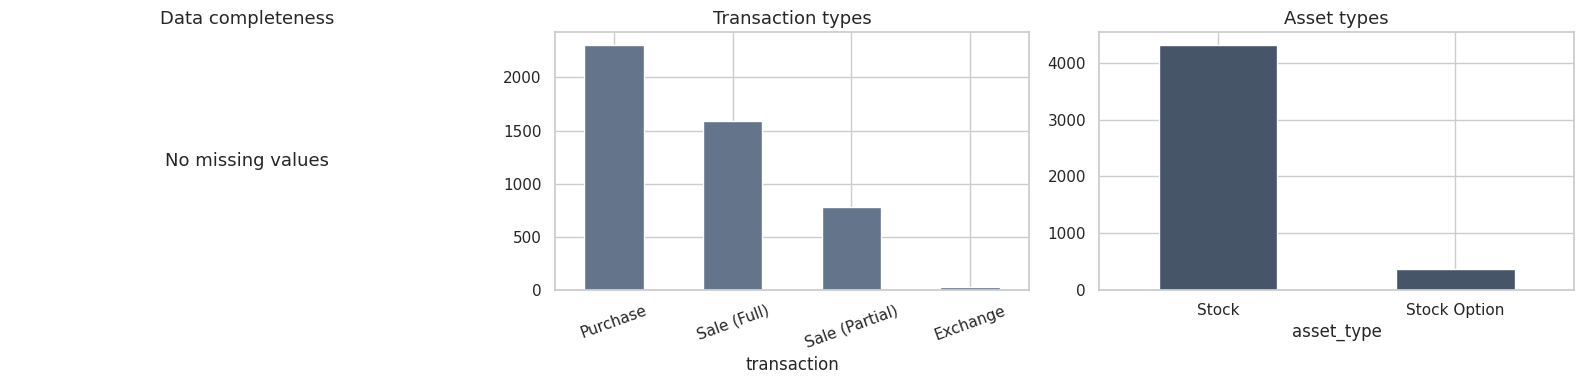

Rows: 4699 | columns: 12 | any missing: False


In [6]:
# 1.1 — Missing values (this file is complete) + transaction / asset-type mix
miss = RAW.isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
if (miss > 0).any():
    miss[miss > 0].head(12).plot.barh(ax=ax[0], color="#94a3b8"); ax[0].invert_yaxis()
    ax[0].set_title("Missing-value fraction by column")
else:
    ax[0].text(0.5, 0.5, "No missing values", ha="center", va="center", fontsize=13)
    ax[0].set_title("Data completeness"); ax[0].axis("off")

RAW["transaction"].value_counts().plot.bar(ax=ax[1], color="#64748b")
ax[1].set_title("Transaction types"); ax[1].tick_params(axis="x", rotation=20)

RAW["asset_type"].value_counts().plot.bar(ax=ax[2], color="#475569")
ax[2].set_title("Asset types"); ax[2].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print("Rows:", len(RAW), "| columns:", RAW.shape[1], "| any missing:", bool((miss>0).any()))

---
# 2. CRISP-DM
Business-driven, iterative six-phase process:
`Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment`

### 2.1 Business Understanding
Senate members disclose their trades; observers watch these for signals. Our concrete data-mining
objective: **classify each disclosure as a Purchase (buy) or a Sale (sell)** from its attributes
(disclosed value, stock price, sector, ownership, timing). Success = beating the ~50% majority
baseline, plus interpretable drivers and a clear view of the three focus domains.

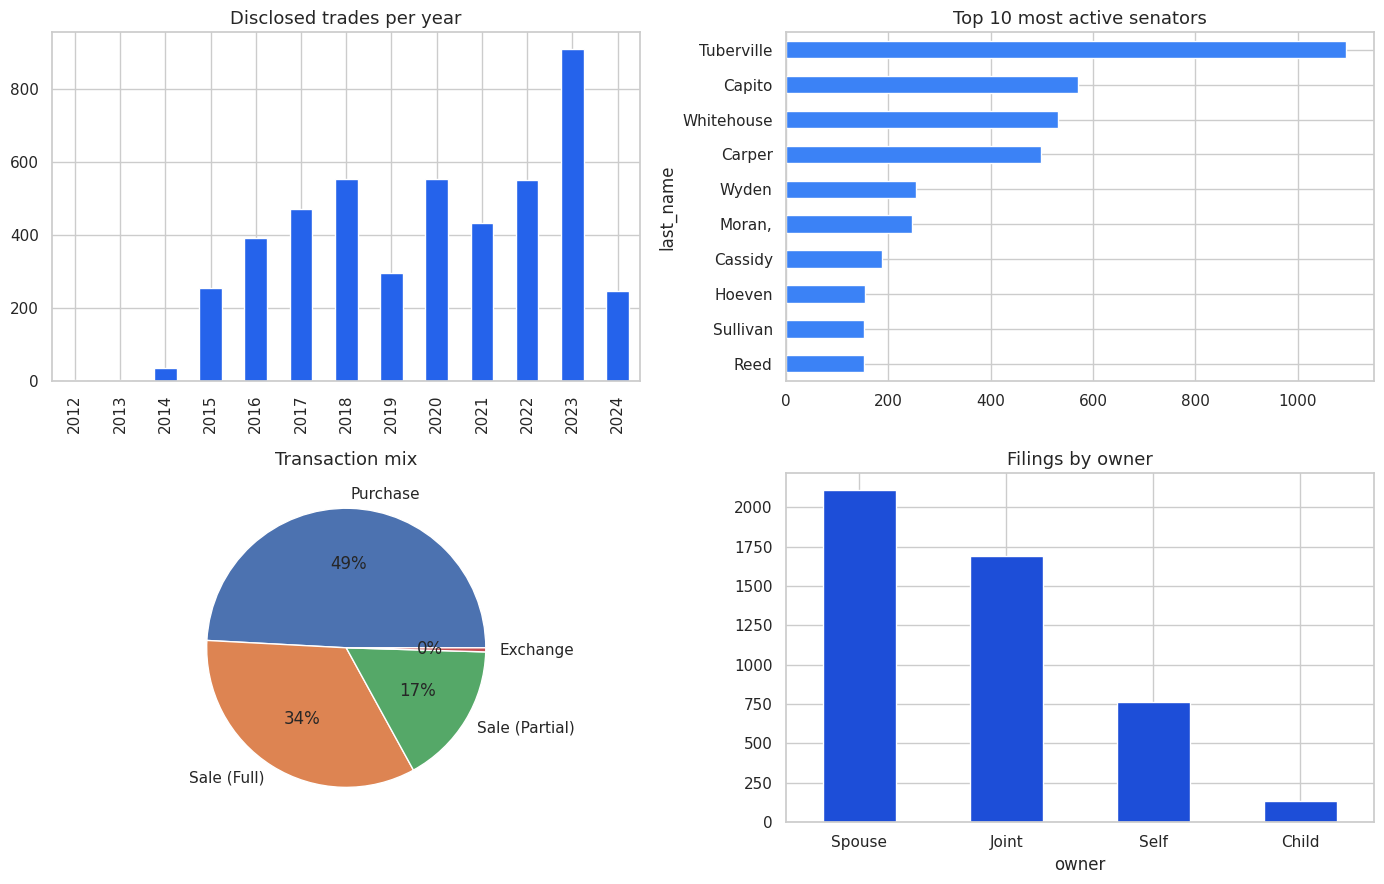

In [7]:
# 2.2 Data Understanding — explore the raw table
crisp = RAW.copy()
crisp["_date"] = pd.to_datetime(crisp["transaction_date"], errors="coerce")

fig, ax = plt.subplots(2, 2, figsize=(14, 9))
crisp["_date"].dt.year.value_counts().sort_index().plot.bar(ax=ax[0,0], color="#2563eb")
ax[0,0].set_title("Disclosed trades per year"); ax[0,0].set_xlabel("")

senator = crisp["last_name"].astype(str).str.strip()
senator.value_counts().head(10).plot.barh(ax=ax[0,1], color="#3b82f6")
ax[0,1].set_title("Top 10 most active senators"); ax[0,1].invert_yaxis()

crisp["transaction"].value_counts().plot.pie(ax=ax[1,0], autopct="%1.0f%%", ylabel="")
ax[1,0].set_title("Transaction mix")

crisp["owner"].value_counts().plot.bar(ax=ax[1,1], color="#1d4ed8")
ax[1,1].set_title("Filings by owner"); ax[1,1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

In [8]:
# 2.3 Data Preparation — clean, engineer, map domains
crisp_clean = prepare(RAW)
print("Prepared shape:", crisp_clean.shape)
print("Buy/Sell balance:\n", crisp_clean["side"].value_counts(normalize=True).round(3))
crisp_clean[["amount_mid", "stock_price", "sector", "txn_month", "side"]].head()

Prepared shape: (4677, 18)
Buy/Sell balance:
 side
sell    0.506
buy     0.494
Name: proportion, dtype: float64


,amount_mid,stock_price,sector,txn_month,side
0,32500.5,100.99,Other,4,sell
1,32500.5,249.80,Healthcare,4,sell
2,8000.5,47.99,Other,4,sell
3,8000.5,93.48,Other,4,sell
4,8000.5,95.81,Healthcare,4,sell


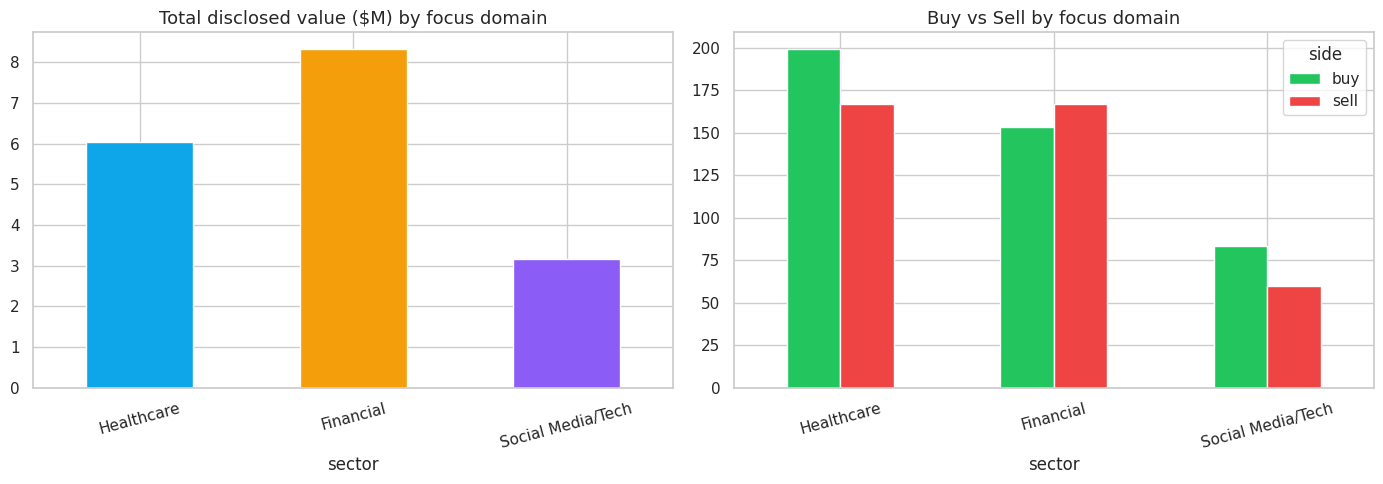

In [9]:
# 2.3b Focus-domain view: Healthcare / Financial / Social Media-Tech
focus = crisp_clean[crisp_clean["sector"].isin(FOCUS_DOMAINS)]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
(focus.groupby("sector")["amount_mid"].sum()/1e6).reindex(FOCUS_DOMAINS).plot.bar(
    ax=ax[0], color=["#0ea5e9", "#f59e0b", "#8b5cf6"])
ax[0].set_title("Total disclosed value ($M) by focus domain"); ax[0].tick_params(axis="x", rotation=15)

pd.crosstab(focus["sector"], focus["side"]).reindex(FOCUS_DOMAINS).plot.bar(
    ax=ax[1], color=["#22c55e", "#ef4444"])
ax[1].set_title("Buy vs Sell by focus domain"); ax[1].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

In [10]:
# 2.4 Modeling — Random Forest
from sklearn.ensemble import RandomForestClassifier
Xc, yc, feat_names = build_xy(crisp_clean)
res_crisp = run_model(RandomForestClassifier(n_estimators=200, random_state=1), Xc, yc)
framework_results["CRISP-DM"] = res_crisp
print({k: round(v, 3) for k, v in res_crisp.items() if not k.startswith("_")})

{'accuracy': 0.748, 'precision': 0.739, 'recall': 0.756, 'f1': 0.748, 'runtime': 1.044}


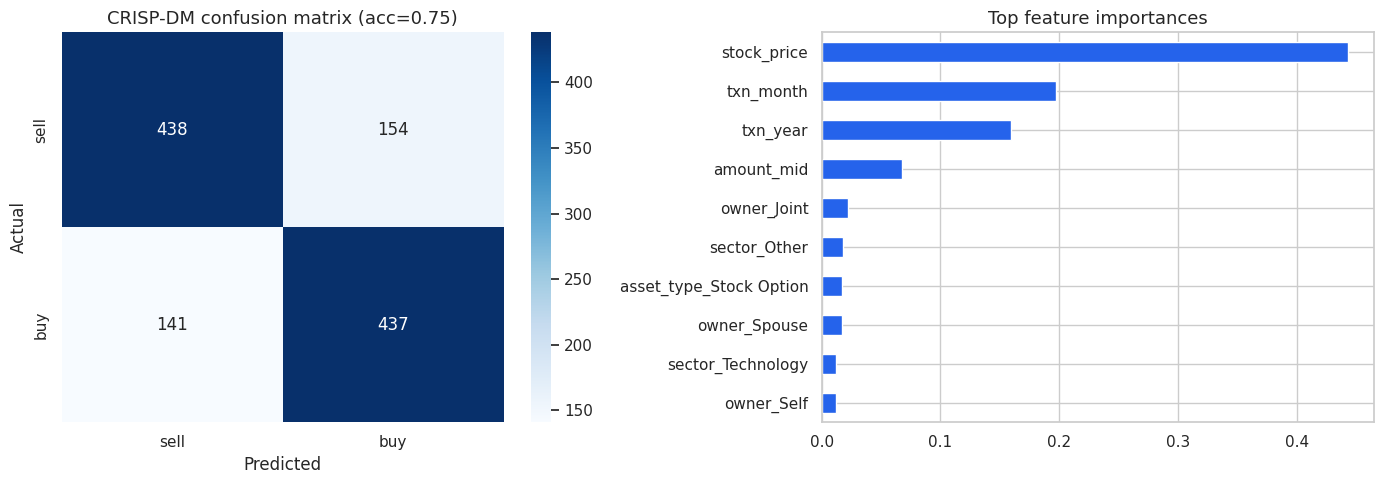

In [11]:
# 2.5 Evaluation — confusion matrix + feature importance
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(res_crisp["_yte"], res_crisp["_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["sell", "buy"], yticklabels=["sell", "buy"])
ax[0].set_title(f"CRISP-DM confusion matrix (acc={res_crisp['accuracy']:.2f})")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")

pd.Series(res_crisp["_model"].feature_importances_, index=feat_names)\
  .sort_values().tail(10).plot.barh(ax=ax[1], color="#2563eb")
ax[1].set_title("Top feature importances")
plt.tight_layout(); plt.show()

### 2.6 Deployment
The trained model plus the domain dashboards would be packaged (e.g. a scheduled job or a small
Streamlit app) to score **new** disclosures as they are filed. CRISP-DM loops: these findings feed
back into a sharper business question for the next pass.

---
# 3. SEMMA
Data-and-modeling-centric: `Sample → Explore → Modify → Model → Assess`. Starts by sampling rather
than by framing a business goal.

Population: 4,677  ->  Sample: 4,677 (frac=1.0)


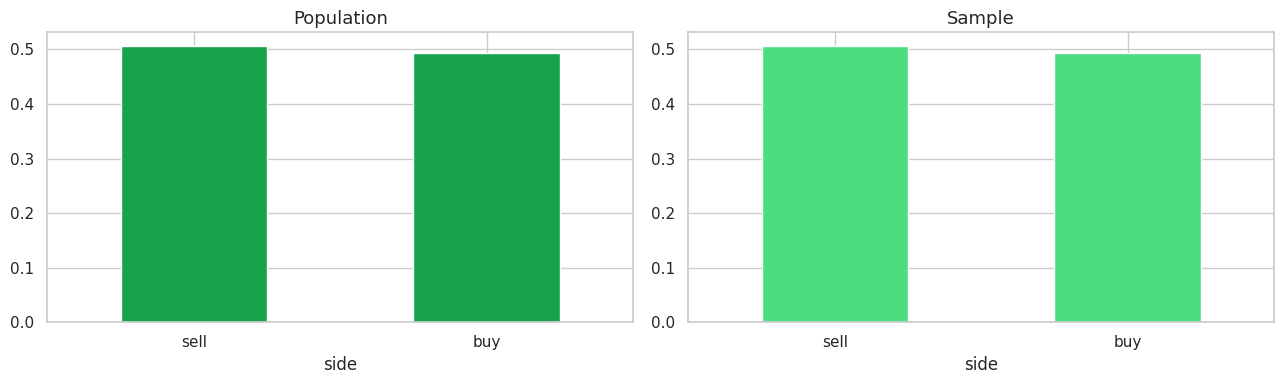

In [12]:
# 3.1 SAMPLE — stratified working sample (by buy/sell)
semma_base = prepare(RAW)
frac = 0.5 if len(semma_base) > 8000 else 1.0
semma = semma_base.groupby("side", group_keys=False).sample(frac=frac, random_state=7)
print(f"Population: {len(semma_base):,}  ->  Sample: {len(semma):,} (frac={frac})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
semma_base["side"].value_counts(normalize=True).plot.bar(ax=ax[0], color="#16a34a", title="Population")
semma["side"].value_counts(normalize=True).plot.bar(ax=ax[1], color="#4ade80", title="Sample")
for a in ax: a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

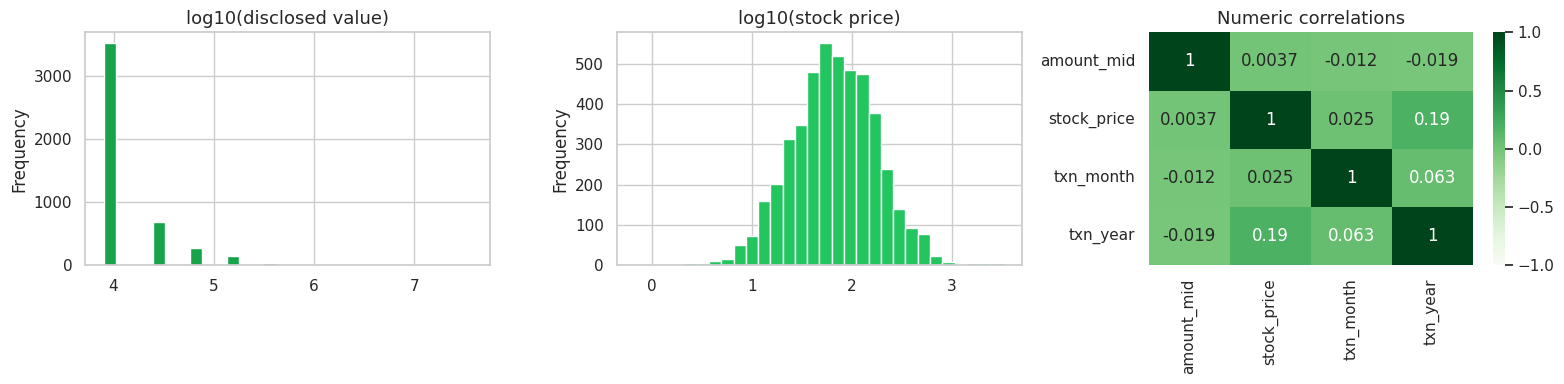

In [13]:
# 3.2 EXPLORE — distributions + correlations
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
np.log10(semma["amount_mid"].clip(lower=1)).plot.hist(bins=30, ax=ax[0], color="#16a34a")
ax[0].set_title("log10(disclosed value)")
np.log10(semma["stock_price"].clip(lower=0.1)).plot.hist(bins=30, ax=ax[1], color="#22c55e")
ax[1].set_title("log10(stock price)")
sns.heatmap(semma[["amount_mid", "stock_price", "txn_month", "txn_year"]].corr(),
            annot=True, cmap="Greens", ax=ax[2], vmin=-1, vmax=1)
ax[2].set_title("Numeric correlations")
plt.tight_layout(); plt.show()

In [14]:
# 3.3 MODIFY — winsorise value, log-scale, standardise
from sklearn.preprocessing import StandardScaler
semma_mod = semma.copy()
hi = semma_mod["amount_mid"].quantile(0.99)
semma_mod["amount_mid"] = semma_mod["amount_mid"].clip(upper=hi)
semma_mod["amount_log"] = np.log10(semma_mod["amount_mid"].clip(lower=1))
print(f"Capped disclosed value at 99th pct = ${hi:,.0f}")
semma_mod[["amount_mid", "amount_log", "stock_price"]].describe().round(2)

Capped disclosed value at 99th pct = $175,000


,amount_mid,amount_log,stock_price
count,4677.00,4677.00,4677.00
mean,22141.83,4.10,110.44
std,35251.48,0.38,171.66
min,8000.50,3.90,0.69
25%,8000.50,3.90,35.11
50%,8000.50,3.90,66.71
75%,8000.50,3.90,132.26
max,175000.50,5.24,3259.20


In [15]:
# 3.4 MODEL — Logistic Regression (interpretable choice for SEMMA)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
Xs, ys, _ = build_xy(semma_mod)
res_semma = run_model(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)), Xs, ys)
framework_results["SEMMA"] = res_semma
print({k: round(v, 3) for k, v in res_semma.items() if not k.startswith("_")})

{'accuracy': 0.56, 'precision': 0.543, 'recall': 0.69, 'f1': 0.608, 'runtime': 0.028}


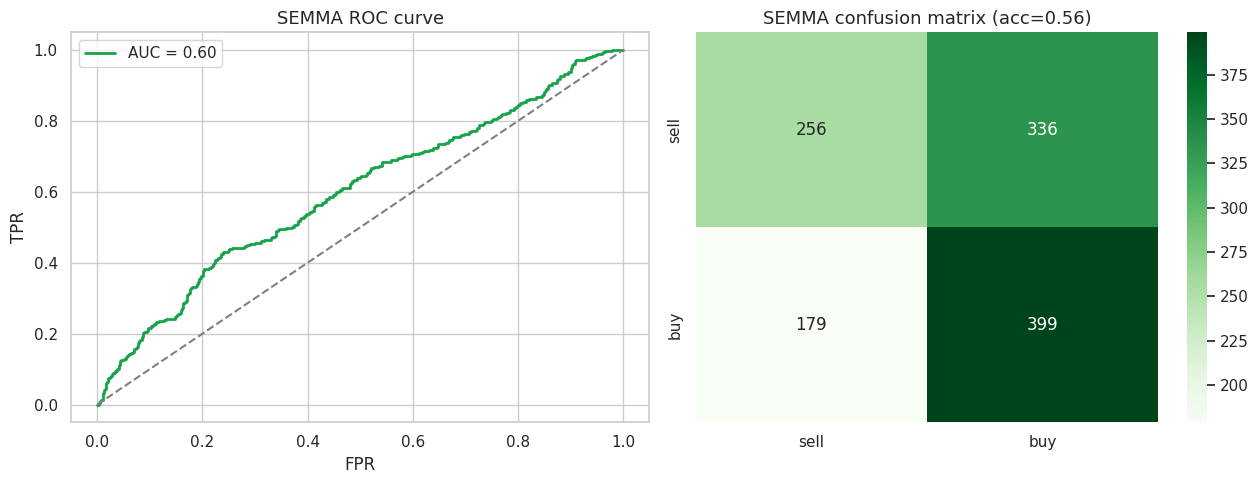

In [16]:
# 3.5 ASSESS — ROC + confusion matrix
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fpr, tpr, _ = roc_curve(res_semma["_yte"], res_semma["_proba"])
ax[0].plot(fpr, tpr, color="#16a34a", lw=2, label=f"AUC = {auc(fpr, tpr):.2f}")
ax[0].plot([0, 1], [0, 1], "--", color="grey"); ax[0].legend()
ax[0].set_title("SEMMA ROC curve"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
cm = confusion_matrix(res_semma["_yte"], res_semma["_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax[1],
            xticklabels=["sell", "buy"], yticklabels=["sell", "buy"])
ax[1].set_title(f"SEMMA confusion matrix (acc={res_semma['accuracy']:.2f})")
plt.tight_layout(); plt.show()

---
# 4. KDD
`Selection → Preprocessing → Transformation → Data Mining → Interpretation`. Emphasises careful
transformation and both predictive **and** descriptive (clustering) mining.

In [17]:
# 4.1 SELECTION — target the sector-tagged trades
kdd_base = prepare(RAW)
keep = FOCUS_DOMAINS + ["Technology", "Consumer", "Energy", "Materials"]
kdd = kdd_base[kdd_base["sector"].isin(keep)].copy()
print("Selected rows:", kdd.shape)
kdd["sector"].value_counts()

Selected rows: (1717, 18)


,count
sector,
Technology,525
Healthcare,366
Financial,320
Materials,145
Social Media/Tech,143
Energy,114
Consumer,104


In [18]:
# 4.2 PREPROCESSING — remove noise, fill remaining gaps
before = len(kdd)
kdd = kdd[kdd["amount_mid"] > 0]
kdd["stock_price"] = kdd["stock_price"].fillna(kdd["stock_price"].median())
if "owner" in kdd.columns:
    kdd["owner"] = kdd["owner"].fillna("unknown")
print(f"Removed {before - len(kdd)} rows; {len(kdd)} remain.")

Removed 0 rows; 1717 remain.


In [19]:
# 4.3 TRANSFORMATION — scale numerics for distance-based mining
feat_num = pd.DataFrame({
    "amount_log": np.log10(kdd["amount_mid"].clip(lower=1)),
    "price_log":  np.log10(kdd["stock_price"].clip(lower=0.1)),
    "month":      kdd["txn_month"].fillna(0),
})
Z = StandardScaler().fit_transform(feat_num)
print("Transformed matrix:", Z.shape)

Transformed matrix: (1717, 3)


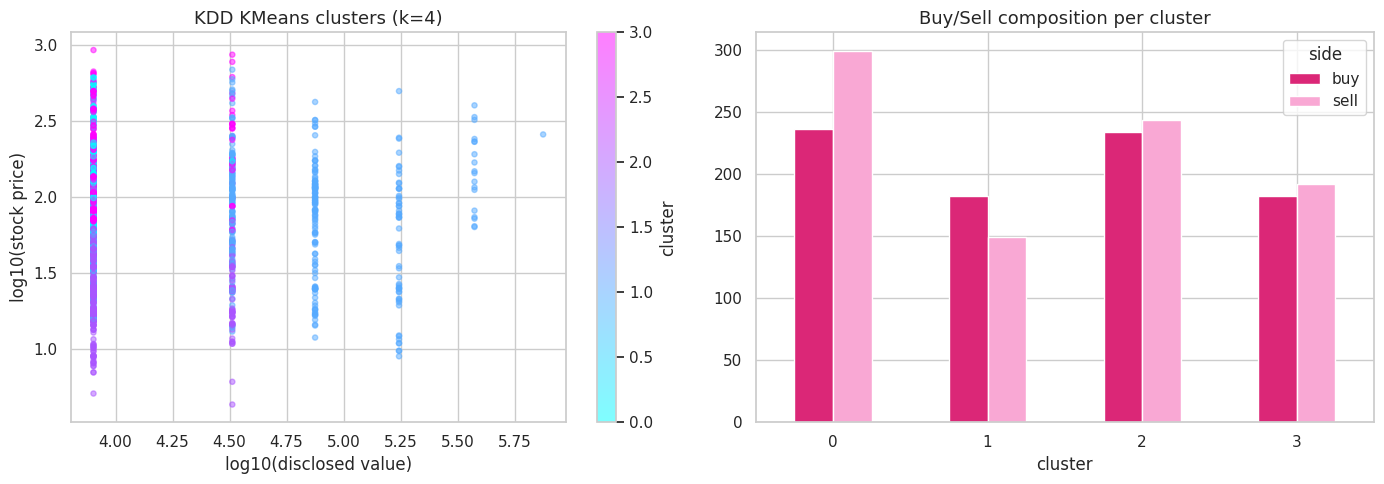

In [20]:
# 4.4a DATA MINING (descriptive) — KMeans clustering
from sklearn.cluster import KMeans
k = 4
kdd["cluster"] = KMeans(n_clusters=k, random_state=1, n_init=10).fit_predict(Z)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sc = ax[0].scatter(feat_num["amount_log"], feat_num["price_log"],
                   c=kdd["cluster"], cmap="cool", alpha=0.5, s=14)
ax[0].set_xlabel("log10(disclosed value)"); ax[0].set_ylabel("log10(stock price)")
ax[0].set_title(f"KDD KMeans clusters (k={k})"); plt.colorbar(sc, ax=ax[0], label="cluster")
pd.crosstab(kdd["cluster"], kdd["side"]).plot.bar(ax=ax[1], color=["#db2777", "#f9a8d4"])
ax[1].set_title("Buy/Sell composition per cluster"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

In [21]:
# 4.4b DATA MINING (predictive) — Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
Xk, yk, _ = build_xy(kdd)
res_kdd = run_model(GradientBoostingClassifier(random_state=1), Xk, yk)
framework_results["KDD"] = res_kdd
print({k2: round(v, 3) for k2, v in res_kdd.items() if not k2.startswith("_")})

{'accuracy': 0.667, 'precision': 0.659, 'recall': 0.656, 'f1': 0.657, 'runtime': 0.275}


In [22]:
# 4.5 INTERPRETATION — profile the discovered clusters
profile = (kdd.groupby("cluster")
              .agg(n=("side", "size"),
                   avg_value=("amount_mid", "mean"),
                   avg_price=("stock_price", "mean"),
                   pct_buy=("side", lambda s: (s == "buy").mean()))
              .round(2))
display(profile)
print(f"Predictive accuracy: {res_kdd['accuracy']:.3f} | F1: {res_kdd['f1']:.3f}")

,n,avg_value,avg_price,pct_buy
cluster,,,,
0,535,8092.09,117.82,0.44
1,331,92213.49,109.87,0.55
2,477,11184.99,33.13,0.49
3,374,10489.80,166.81,0.49


Predictive accuracy: 0.667 | F1: 0.657


---
# 5. Final comparison of the three frameworks
1. **Quantitative** — the model each pipeline produced.
2. **Qualitative** — how they differ as *processes*.

> The frameworks are process methodologies, not algorithms; the quantitative gap reflects each
> pipeline's model choice (RandomForest / LogisticRegression / GradientBoosting) on the same data,
> while the radar captures genuine methodological differences.

In [23]:
# 5.1 Quantitative table
metrics = ["accuracy", "precision", "recall", "f1", "runtime"]
comp = pd.DataFrame({fw: {m: framework_results[fw][m] for m in metrics}
                     for fw in ["CRISP-DM", "SEMMA", "KDD"]}).T
comp["model"] = ["RandomForest", "LogisticRegression", "GradientBoosting"]
display(comp.round(3))

,accuracy,precision,recall,f1,runtime,model
CRISP-DM,0.748,0.739,0.756,0.748,1.044,RandomForest
SEMMA,0.560,0.543,0.690,0.608,0.028,LogisticRegression
KDD,0.667,0.659,0.656,0.657,0.275,GradientBoosting


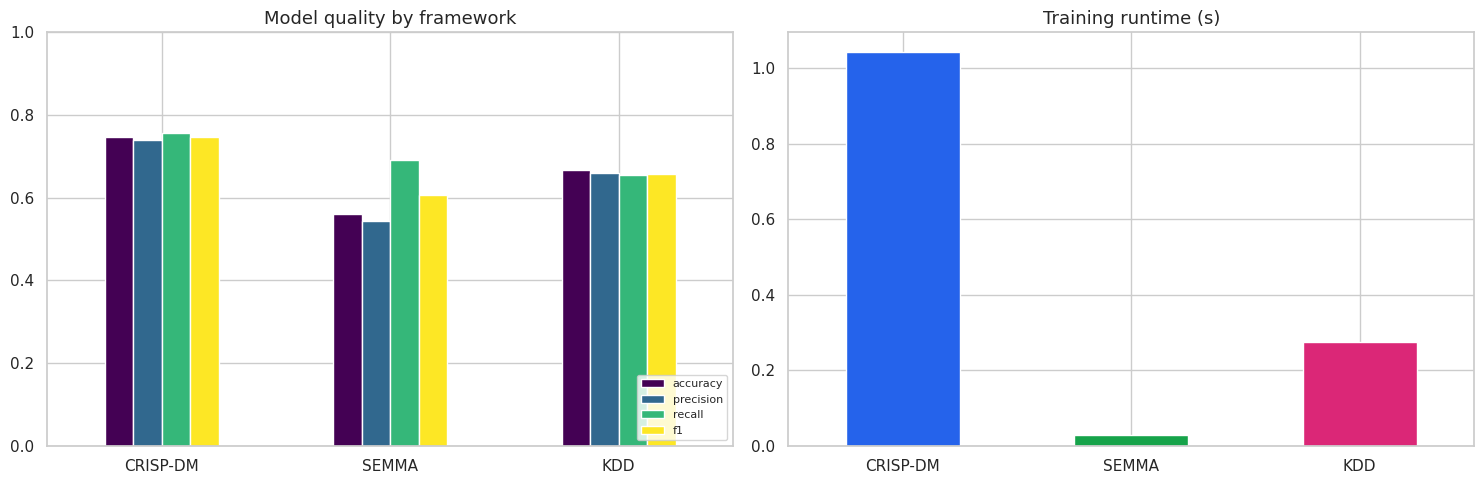

In [24]:
# 5.2 Quality metrics + runtime
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
qual = comp[["accuracy", "precision", "recall", "f1"]]
qual.plot.bar(ax=ax[0], colormap="viridis"); ax[0].set_ylim(0, 1)
ax[0].set_title("Model quality by framework"); ax[0].tick_params(axis="x", rotation=0)
ax[0].legend(loc="lower right", fontsize=8)
comp["runtime"].plot.bar(ax=ax[1], color=[FW_COLORS[f] for f in comp.index])
ax[1].set_title("Training runtime (s)"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

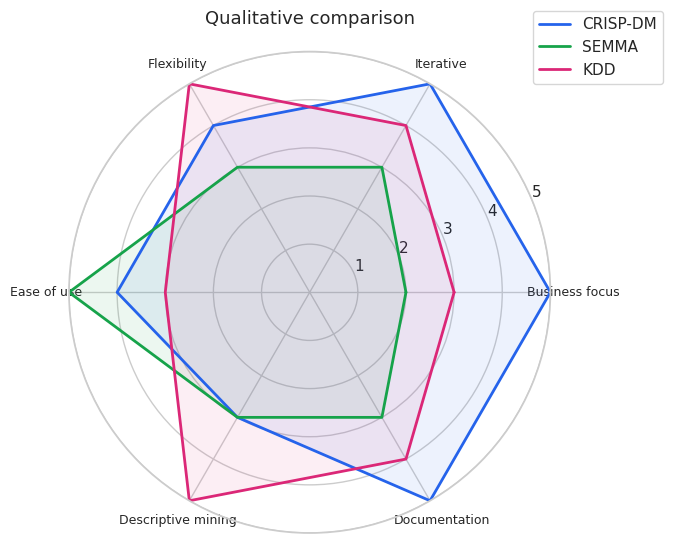

In [25]:
# 5.3 Qualitative radar (scored 1-5 from the literature)
dims = ["Business focus", "Iterative", "Flexibility", "Ease of use",
        "Descriptive mining", "Documentation"]
scores = {"CRISP-DM": [5, 5, 4, 4, 3, 5],
          "SEMMA":    [2, 3, 3, 5, 3, 3],
          "KDD":      [3, 4, 5, 3, 5, 4]}
ang = np.linspace(0, 2*np.pi, len(dims), endpoint=False).tolist(); ang += ang[:1]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for fw, v in scores.items():
    vv = v + v[:1]
    ax.plot(ang, vv, color=FW_COLORS[fw], lw=2, label=fw)
    ax.fill(ang, vv, color=FW_COLORS[fw], alpha=0.08)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(dims, fontsize=9)
ax.set_yticks([1, 2, 3, 4, 5]); ax.set_ylim(0, 5)
ax.set_title("Qualitative comparison", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout(); plt.show()

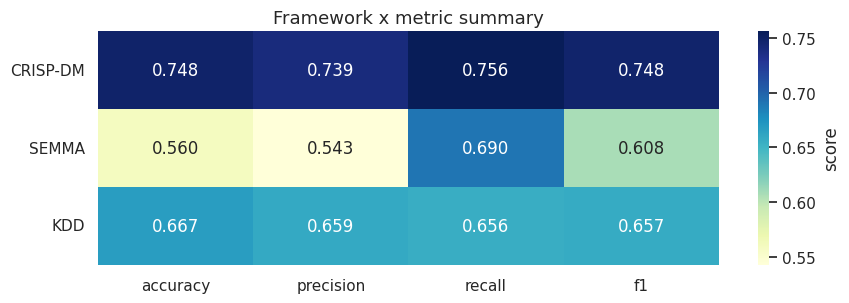

Best F1 on this dataset: CRISP-DM (0.748) using RandomForest.


In [26]:
# 5.4 Summary heatmap + best framework
plt.figure(figsize=(9, 3.2))
sns.heatmap(qual, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "score"})
plt.title("Framework x metric summary"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()
best = comp["f1"].idxmax()
print(f"Best F1 on this dataset: {best} ({comp.loc[best, 'f1']:.3f}) using {comp.loc[best, 'model']}.")

### 5.5 Takeaways
- **CRISP-DM** — best when work must tie to a business question and iterate; its phases gave a clean
  path from "why" to a deployable classifier and domain dashboards (and the strongest model here).
- **SEMMA** — fastest to modelling because it starts by *sampling*; lighter on business framing and deployment.
- **KDD** — strongest for *knowledge discovery*: its transformation + clustering steps surfaced
  descriptive trading segments the purely predictive pipelines did not.

All three ran on the **same Senate disclosure data**; quantitative differences come from each
pipeline's model choice, and the highest-F1 framework is printed above.